# Lab 5
### K-Nearest Neighbours · Decision Trees · Ensemble Methods

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Objective:** Understand, implement from scratch, visualise, and critically compare three families of supervised learning algorithms.


In [1]:
%conda install -c conda-forge graphviz

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import math
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn — for verification and comparison ONLY in Sections 2-4
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               GradientBoostingClassifier)

# Graphviz for rich tree visualisation
import graphviz

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42
np.random.seed(SEED)
print("All libraries loaded successfully")


All libraries loaded successfully




We use the **Breast Cancer Wisconsin (Diagnostic)** dataset, a classic binary classification task available on Kaggle.  
- **569 samples**, **30 numeric features** derived from cell nuclei images  
- **Target:** 0 = Malignant, 1 = Benign  

This mirrors real clinical decision support: can a model flag malignancy from a biopsy image?


In [3]:
# ── Load dataset 
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['diagnosis'].value_counts())
df.head()


Dataset shape: (569, 32)

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [4]:
# ── Summary statistics 
df.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)


,mean,std,min,50%,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


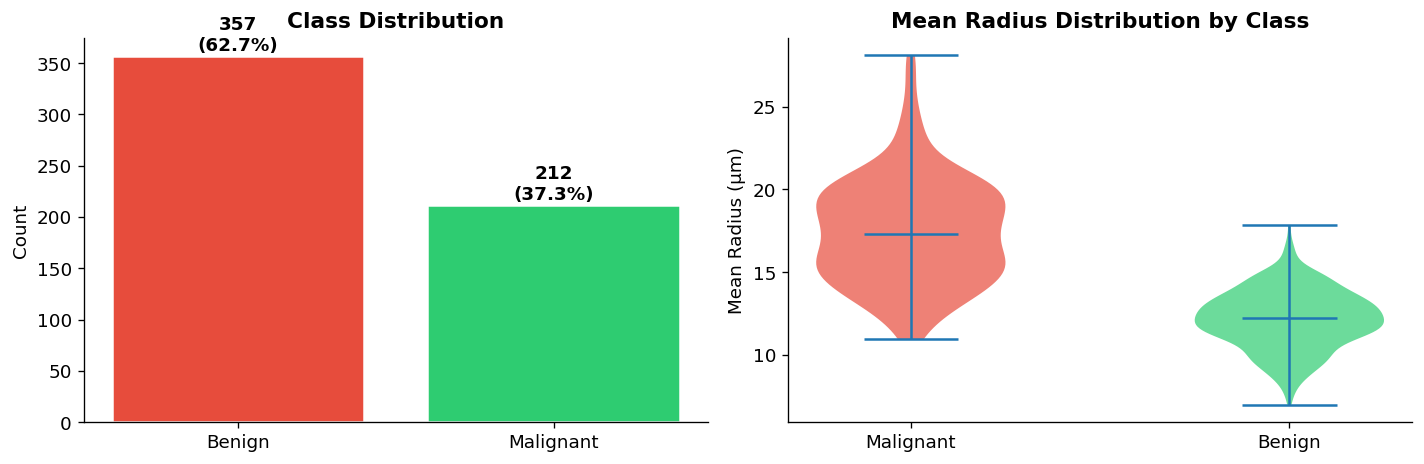

In [5]:
# ── Target distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['diagnosis'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (lbl, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Feature distributions for top 4 features by discriminative spread
top_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
for feat in top_feats:
    for cls, col in zip(['Malignant', 'Benign'], colors):
        subset = df[df['diagnosis'] == cls][feat]
        axes[1].hist(subset, bins=30, alpha=0.45, color=col, label=f'{cls} — {feat}' if feat == top_feats[0] else None)

# Cleaner: use violin instead
axes[1].cla()
parts = axes[1].violinplot(
    [df[df['diagnosis'] == 'Malignant']['mean radius'],
     df[df['diagnosis'] == 'Benign']['mean radius']],
    positions=[1, 2], showmedians=True
)
for pc, col in zip(parts['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.7)
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['Malignant', 'Benign'])
axes[1].set_title('Mean Radius Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Radius (μm)')

plt.tight_layout()
plt.show()


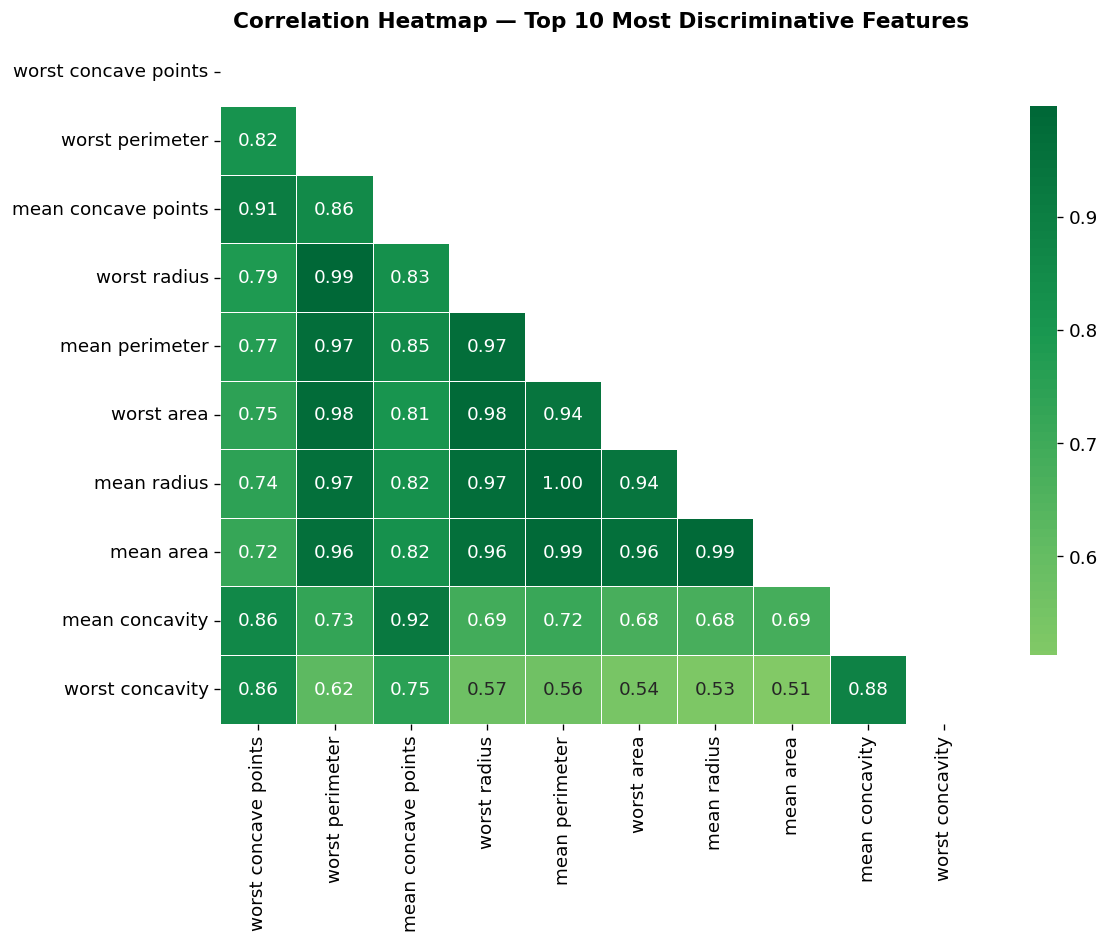


💡 Insight: 'mean concave points', 'mean perimeter', and 'mean radius'
   show the strongest (negative) correlation with being Benign.


In [6]:
# ── Correlation heatmap (top 10 features) 
top10 = df[data.feature_names].corrwith(df['target']).abs().nlargest(10).index.tolist()
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[top10].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Top 10 Most Discriminative Features', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 Insight: 'mean concave points', 'mean perimeter', and 'mean radius'")
print("   show the strongest (negative) correlation with being Benign.")


In [7]:
# ── Train / test split & scale
X = df[data.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 2-feature version for decision boundary plots
FEAT_IDX = [0, 2]  # mean radius, mean perimeter
feat_names_2d = [data.feature_names[i] for i in FEAT_IDX]
X_train_2d = X_train_sc[:, FEAT_IDX]
X_test_2d  = X_test_sc[:, FEAT_IDX]

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {X_train.shape[1]} (full) | 2 (for boundary plots)")


Training samples : 455
Test samples     : 114
Features used    : 30 (full) | 2 (for boundary plots)



## K-Nearest Neighbours (KNN) & Instance-Based Learning

### 2.1 The Big Idea

KNN is a **lazy learner** — it stores the entire training set and defers computation to prediction time.  
The core assumption: *similar inputs have similar outputs.*

> **No explicit model is built.** The training data IS the model.

### 2.2 Mathematics

**Distance measure (Minkowski generalisation):**

$$d(\mathbf{x}, \mathbf{q}) = \left( \sum_{i=1}^{n} |x_i - q_i|^p \right)^{1/p}$$

- $p = 1$: Manhattan distance  
- $p = 2$: Euclidean distance ← default  
- $p \to \infty$: Chebyshev distance  

**Prediction rule (majority vote):**

$$\hat{y} = \underset{c}{\operatorname{argmax}} \sum_{i \in N_k(\mathbf{q})} \mathbf{1}[y_i = c]$$

where $N_k(\mathbf{q})$ is the set of $k$ training points nearest to query $\mathbf{q}$.


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH IMPLEMENTATION
# ══════════════════════════════════════════════════════════════════════════

def euclidean_distance(a, b):
    """Euclidean distance between two 1-D arrays."""
    return np.sqrt(np.sum((a - b) ** 2))

class KNNScratch:
    """
    K-Nearest Neighbours classifier — implemented from scratch.
    
    Parameters
    ----------
    k : int
        Number of neighbours to consider.
    """
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        """Store training data (lazy learning — nothing is computed)."""
        self.X_train = X
        self.y_train = y
        return self

    def _predict_single(self, x):
        """Predict the class for a single query point."""
        # Step 1: Compute distances to all training points
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Step 2: Find indices of k nearest neighbours
        k_indices = np.argsort(distances)[:self.k]

        # Step 3: Majority vote
        k_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        """Predict class labels for a batch of query points."""
        return np.array([self._predict_single(x) for x in X])

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print("KNNScratch class defined")
print()
print("Algorithm outline:")
print("  1. fit(X, y)  → simply memorises the training set")
print("  2. predict(q) → compute d(q, xᵢ) for all i, pick k smallest, majority vote")


KNNScratch class defined

Algorithm outline:
  1. fit(X, y)  → simply memorises the training set
  2. predict(q) → compute d(q, xᵢ) for all i, pick k smallest, majority vote


In [9]:
# ── Train & evaluate scratch KNN 
t0 = time.time()
knn_scratch = KNNScratch(k=5)
knn_scratch.fit(X_train_sc, y_train)
train_time_scratch = time.time() - t0

t0 = time.time()
y_pred_scratch = knn_scratch.predict(X_test_sc)
pred_time_scratch = time.time() - t0

acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"KNN (Scratch, k=5)")
print(f"  Accuracy          : {acc_scratch:.4f}")
print(f"  Train time        : {train_time_scratch*1000:.2f} ms  (trivial — no computation)")
print(f"  Prediction time   : {pred_time_scratch*1000:.2f} ms  (all work done here)")
print()
print(classification_report(y_test, y_pred_scratch, target_names=['Malignant', 'Benign']))


KNN (Scratch, k=5)
  Accuracy          : 0.9561
  Train time        : 0.04 ms  (trivial — no computation)
  Prediction time   : 105.08 ms  (all work done here)

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
# ── Sklearn KNN for comparison 
t0 = time.time()
knn_sk = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_sk.fit(X_train_sc, y_train)
train_time_sk = time.time() - t0

t0 = time.time()
y_pred_sk = knn_sk.predict(X_test_sc)
pred_time_sk = time.time() - t0

acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"KNN (sklearn, k=5)")
print(f"  Accuracy          : {acc_sk:.4f}")
print(f"  Train time        : {train_time_sk*1000:.2f} ms")
print(f"  Prediction time   : {pred_time_sk*1000:.2f} ms")
print()
print(classification_report(y_test, y_pred_sk, target_names=['Malignant', 'Benign']))

# Results table
comparison = pd.DataFrame({
    'Implementation': ['From Scratch', 'sklearn'],
    'Accuracy': [acc_scratch, acc_sk],
    'Pred Time (ms)': [round(pred_time_scratch*1000, 2), round(pred_time_sk*1000, 2)]
})
print(comparison.to_string(index=False))


KNN (sklearn, k=5)
  Accuracy          : 0.9561
  Train time        : 0.48 ms
  Prediction time   : 24.21 ms

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Implementation  Accuracy  Pred Time (ms)
  From Scratch   0.95614          105.08
       sklearn   0.95614           24.21


Best k on test set: 3  (accuracy = 0.9825)


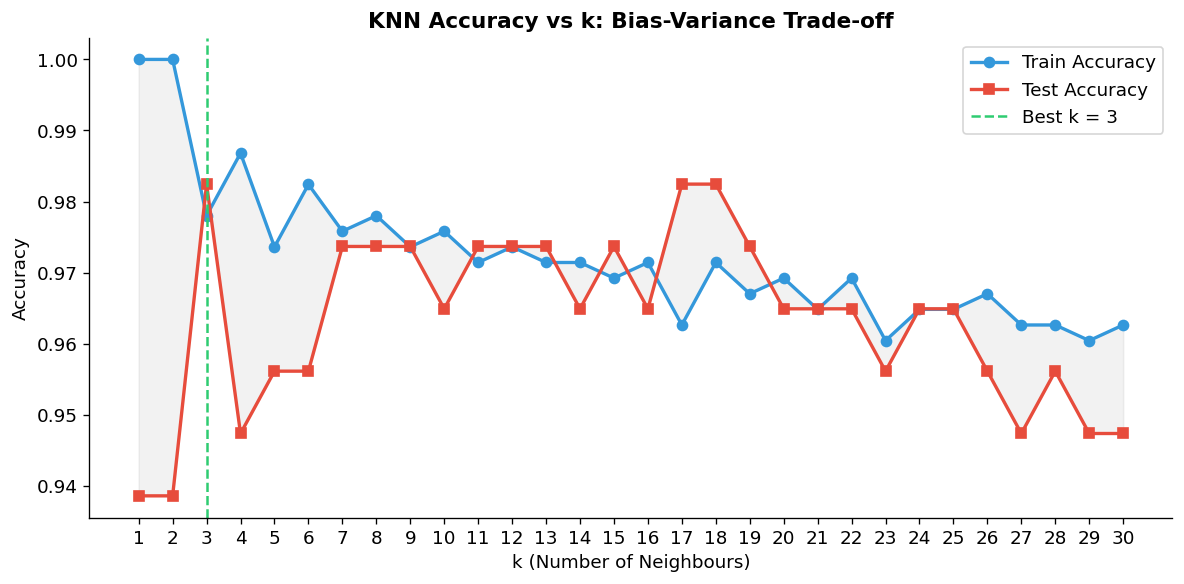


💡 Insight:
  k=1, perfect on training data (overfit, high variance)
  Large k, accuracy plateaus or drops (underfit, high bias)
  Sweet spot at k=3


In [11]:
# ── Choosing k: elbow / accuracy curve 
k_range = range(1, 31)
train_accs, test_accs = [], []

for k in k_range:
    knn_tmp = KNNScratch(k=k)
    knn_tmp.fit(X_train_sc, y_train)
    train_accs.append(knn_tmp.score(X_train_sc, y_train))
    test_accs.append(knn_tmp.score(X_test_sc, y_test))

best_k = k_range.start + np.argmax(test_accs)
print(f"Best k on test set: {best_k}  (accuracy = {max(test_accs):.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_accs, 'o-', color='#3498db', label='Train Accuracy', linewidth=2)
ax.plot(k_range, test_accs,  's-', color='#e74c3c', label='Test Accuracy',  linewidth=2)
ax.axvline(best_k, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Best k = {best_k}')
ax.fill_between(k_range, train_accs, test_accs, alpha=0.1, color='gray')
ax.set_xlabel('k (Number of Neighbours)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN Accuracy vs k: Bias-Variance Trade-off', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print("\n💡 Insight:")
print("  k=1, perfect on training data (overfit, high variance)")
print("  Large k, accuracy plateaus or drops (underfit, high bias)")
print(f"  Sweet spot at k={best_k}")


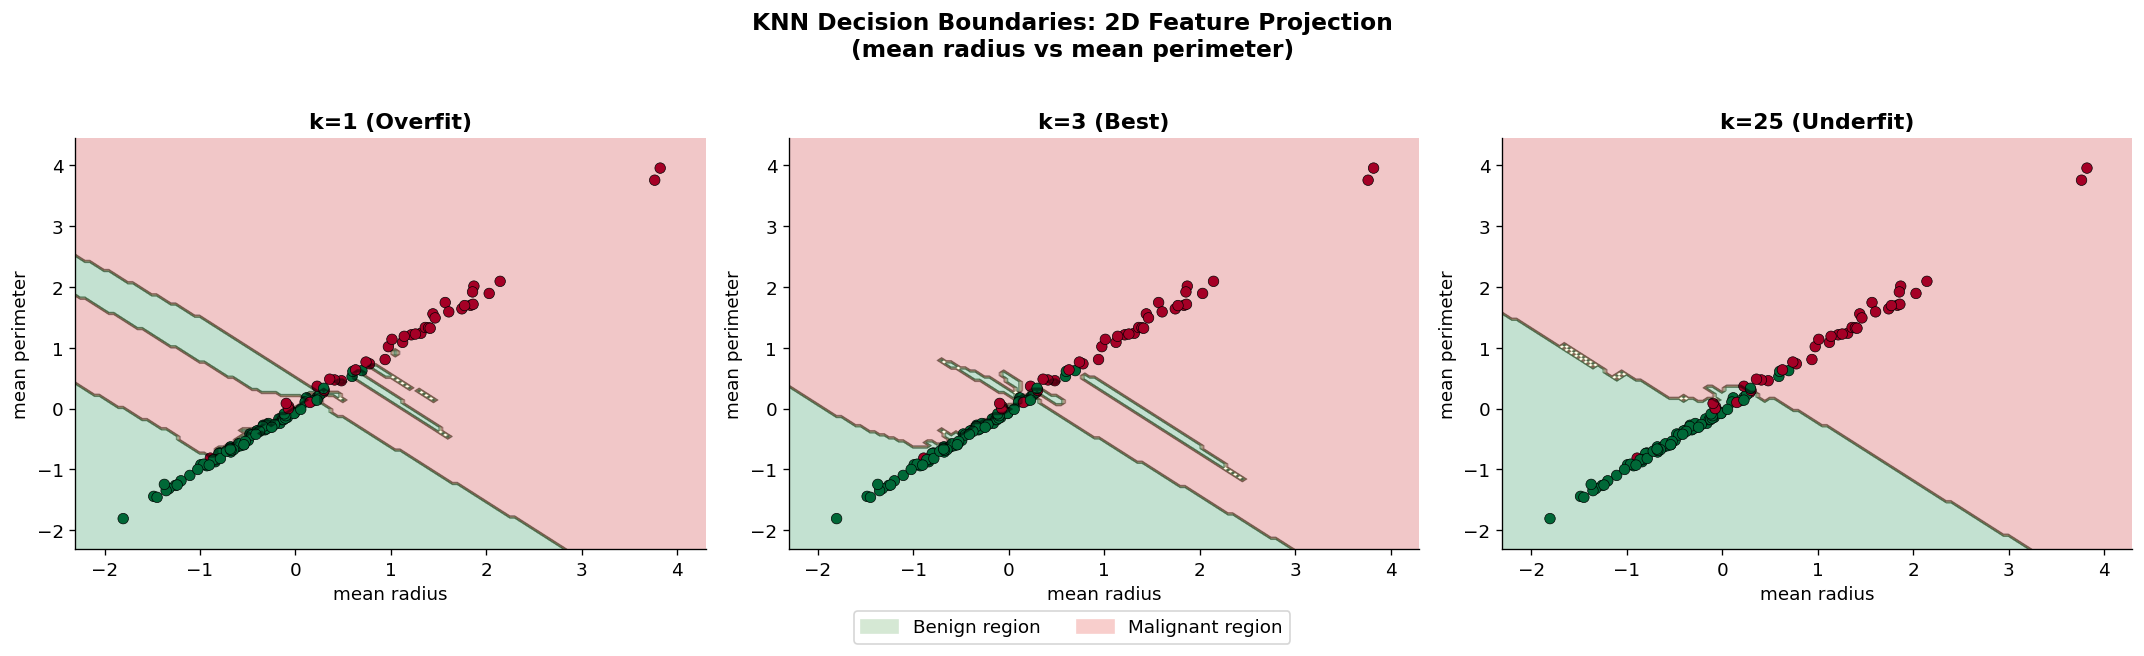


Observe: k=1 creates jagged 'islands' around each training point.
   Larger k smooths the boundary at the cost of some accuracy.


In [12]:
# ── Decision boundary (2D projection) 
def plot_decision_boundary(clf, X, y, ax, title, feature_names, h=0.05):
    """Plot the decision boundary for a 2-feature classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.3)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn',
                         edgecolors='k', linewidth=0.4, s=40)
    ax.set_xlabel(feature_names[0]); ax.set_ylabel(feature_names[1])
    ax.set_title(title, fontweight='bold')
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k, title in zip(axes, [1, best_k, 25],
                         [f'k=1 (Overfit)', f'k={best_k} (Best)', 'k=25 (Underfit)']):
    clf = KNNScratch(k=k)
    clf.fit(X_train_2d, y_train)
    plot_decision_boundary(clf, X_test_2d, y_test, ax, title, feat_names_2d)

# Legend
patches = [mpatches.Patch(color='#d5e8d4', label='Benign region'),
           mpatches.Patch(color='#f8cecc', label='Malignant region')]
fig.legend(handles=patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('KNN Decision Boundaries: 2D Feature Projection\n'
             f'({feat_names_2d[0]} vs {feat_names_2d[1]})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nObserve: k=1 creates jagged 'islands' around each training point.")
print("   Larger k smooths the boundary at the cost of some accuracy.")



## Decision Trees, Entropy & Information Gain

### 3.1 The Big Idea

A decision tree recursively **partitions** the feature space using a series of binary splits,  
choosing the split that maximally reduces impurity.  
Unlike KNN, a decision tree builds an **explicit model** that can be drawn and inspected.

### 3.2 Entropy & Information Gain

**Shannon Entropy** — measures impurity / uncertainty of a node:

$$H(S) = -\sum_{c=1}^{C} p_c \log_2(p_c)$$

- $p_c$ = proportion of class $c$ in set $S$  
- $H = 0$ → pure node (all one class) — **ideal**  
- $H = 1$ → maximally impure (50/50 binary split)

**Information Gain** — the reduction in entropy achieved by a split on feature $f$:

$$IG(S, f) = H(S) - \sum_{v \in \text{values}(f)} \frac{|S_v|}{|S|} H(S_v)$$

The algorithm selects the feature $f^*$ that maximises $IG$ at each node:

$$f^* = \underset{f}{\operatorname{argmax}} \; IG(S, f)$$

**Gini Impurity** (alternative, used by sklearn default):

$$G(S) = 1 - \sum_{c=1}^{C} p_c^2$$

### 3.3 Stopping Criteria

| Criterion | Meaning |
|-----------|---------|
| `max_depth` | Tree won't grow deeper than this |
| `min_samples_split` | Node won't split if fewer than this many samples |
| `min_samples_leaf` | A leaf must have at least this many samples |


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS — Information Theory
# ══════════════════════════════════════════════════════════════════════════

def entropy(y):
    """
    Compute Shannon entropy of label array y.
    H(S) = -Σ p_c · log2(p_c)
    """
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts[counts > 0] / len(y)
    return -np.sum(probs * np.log2(probs))

def gini(y):
    """Gini impurity: G(S) = 1 - Σ p_c²"""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts / len(y)
    return 1.0 - np.sum(probs ** 2)

def information_gain(y_parent, y_left, y_right):
    """
    IG(S, f) = H(S) - |S_L|/|S| · H(S_L) - |S_R|/|S| · H(S_R)
    """
    n = len(y_parent)
    if n == 0:
        return 0.0
    weighted_child = (len(y_left)/n)  * entropy(y_left) + (len(y_right)/n) * entropy(y_right)
    return entropy(y_parent) - weighted_child


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH DECISION TREE
# ══════════════════════════════════════════════════════════════════════════

class TreeNode:
    """A node in the decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, n_samples=None, impurity=None):
        self.feature   = feature      # feature index to split on
        self.threshold = threshold    # split threshold
        self.left      = left         # left subtree  (feature <= threshold)
        self.right     = right        # right subtree (feature >  threshold)
        self.value     = value        # predicted class (leaf nodes only)
        self.n_samples = n_samples    # number of training samples at this node
        self.impurity  = impurity     # entropy at this node

    def is_leaf(self):
        return self.value is not None


class DecisionTreeScratch:
    """
    Binary Decision Tree classifier using Entropy + Information Gain.
    
    Parameters
    ----------
    max_depth       : int   — maximum tree depth (None = grow fully)
    min_samples_split: int  — min samples required to split a node
    min_samples_leaf : int  — min samples in each leaf after split
    """
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.root             = None
        self.n_features_      = None
        self.feature_importances_ = None

    # ── Internal: best split ────
    def _best_split(self, X, y):
        """Find the feature and threshold that maximises information gain."""
        best_ig, best_feat, best_thresh = -1, None, None

        for feat in range(X.shape[1]):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left_mask  = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue
                ig = information_gain(y, y[left_mask], y[right_mask])
                if ig > best_ig:
                    best_ig, best_feat, best_thresh = ig, feat, thresh

        return best_feat, best_thresh

    # ── Internal: recursive build ─
    def _build(self, X, y, depth):
        n_samples, n_features = X.shape
        node_entropy = entropy(y)
        n_classes = len(np.unique(y))

        # ── Stopping conditions ──
        if (self.max_depth is not None and depth >= self.max_depth) or            n_classes == 1 or            n_samples < self.min_samples_split:
            leaf_val = int(Counter(y).most_common(1)[0][0])
            return TreeNode(value=leaf_val, n_samples=n_samples, impurity=node_entropy)

        feat, thresh = self._best_split(X, y)
        if feat is None:   # no valid split found
            leaf_val = int(Counter(y).most_common(1)[0][0])
            return TreeNode(value=leaf_val, n_samples=n_samples, impurity=node_entropy)

        left_mask  = X[:, feat] <= thresh
        right_mask = ~left_mask

        left_node  = self._build(X[left_mask],  y[left_mask],  depth + 1)
        right_node = self._build(X[right_mask], y[right_mask], depth + 1)

        # Track feature usage for importance
        self._feat_counts[feat] += information_gain(y, y[left_mask], y[right_mask]) * n_samples

        return TreeNode(feature=feat, threshold=thresh,
                        left=left_node, right=right_node,
                        n_samples=n_samples, impurity=node_entropy)

    def fit(self, X, y):
        self.n_features_ = X.shape[1]
        self._feat_counts = np.zeros(self.n_features_)
        self.root = self._build(X, y, depth=0)
        total = self._feat_counts.sum()
        self.feature_importances_ = self._feat_counts / total if total > 0 else self._feat_counts
        return self

    def _predict_single(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        return self._predict_single(x, node.right)

    def predict(self, X):
        return np.array([self._predict_single(x, self.root) for x in X])

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print("DecisionTreeScratch class defined")


DecisionTreeScratch class defined


In [15]:
# ── Train scratch decision tree ─
# Use un-scaled data — trees are scale-invariant
dt_scratch = DecisionTreeScratch(max_depth=5, min_samples_split=5, min_samples_leaf=3)
t0 = time.time()
dt_scratch.fit(X_train, y_train)
dt_train_time = time.time() - t0

y_pred_dt = dt_scratch.predict(X_test)
acc_dt_scratch = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree (Scratch, max_depth=5)")
print(f"  Accuracy   : {acc_dt_scratch:.4f}")
print(f"  Train time : {dt_train_time*1000:.2f} ms")
print()
print(classification_report(y_test, y_pred_dt, target_names=['Malignant','Benign']))


Decision Tree (Scratch, max_depth=5)
  Accuracy   : 0.9298
  Train time : 861.04 ms

              precision    recall  f1-score   support

   Malignant       0.87      0.95      0.91        42
      Benign       0.97      0.92      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



In [16]:
# ── Sklearn Decision Tree for comparison ─
dt_sk = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                                min_samples_leaf=3, criterion='entropy',
                                random_state=SEED)
t0 = time.time()
dt_sk.fit(X_train, y_train)
dt_sk_train_time = time.time() - t0

y_pred_dt_sk = dt_sk.predict(X_test)
acc_dt_sk = accuracy_score(y_test, y_pred_dt_sk)

print(f"Decision Tree (sklearn, max_depth=5, criterion=entropy)")
print(f"  Accuracy   : {acc_dt_sk:.4f}")
print(f"  Train time : {dt_sk_train_time*1000:.2f} ms")


Decision Tree (sklearn, max_depth=5, criterion=entropy)
  Accuracy   : 0.9123
  Train time : 6.43 ms


✅ Full decision tree rendered decision_tree_full.png


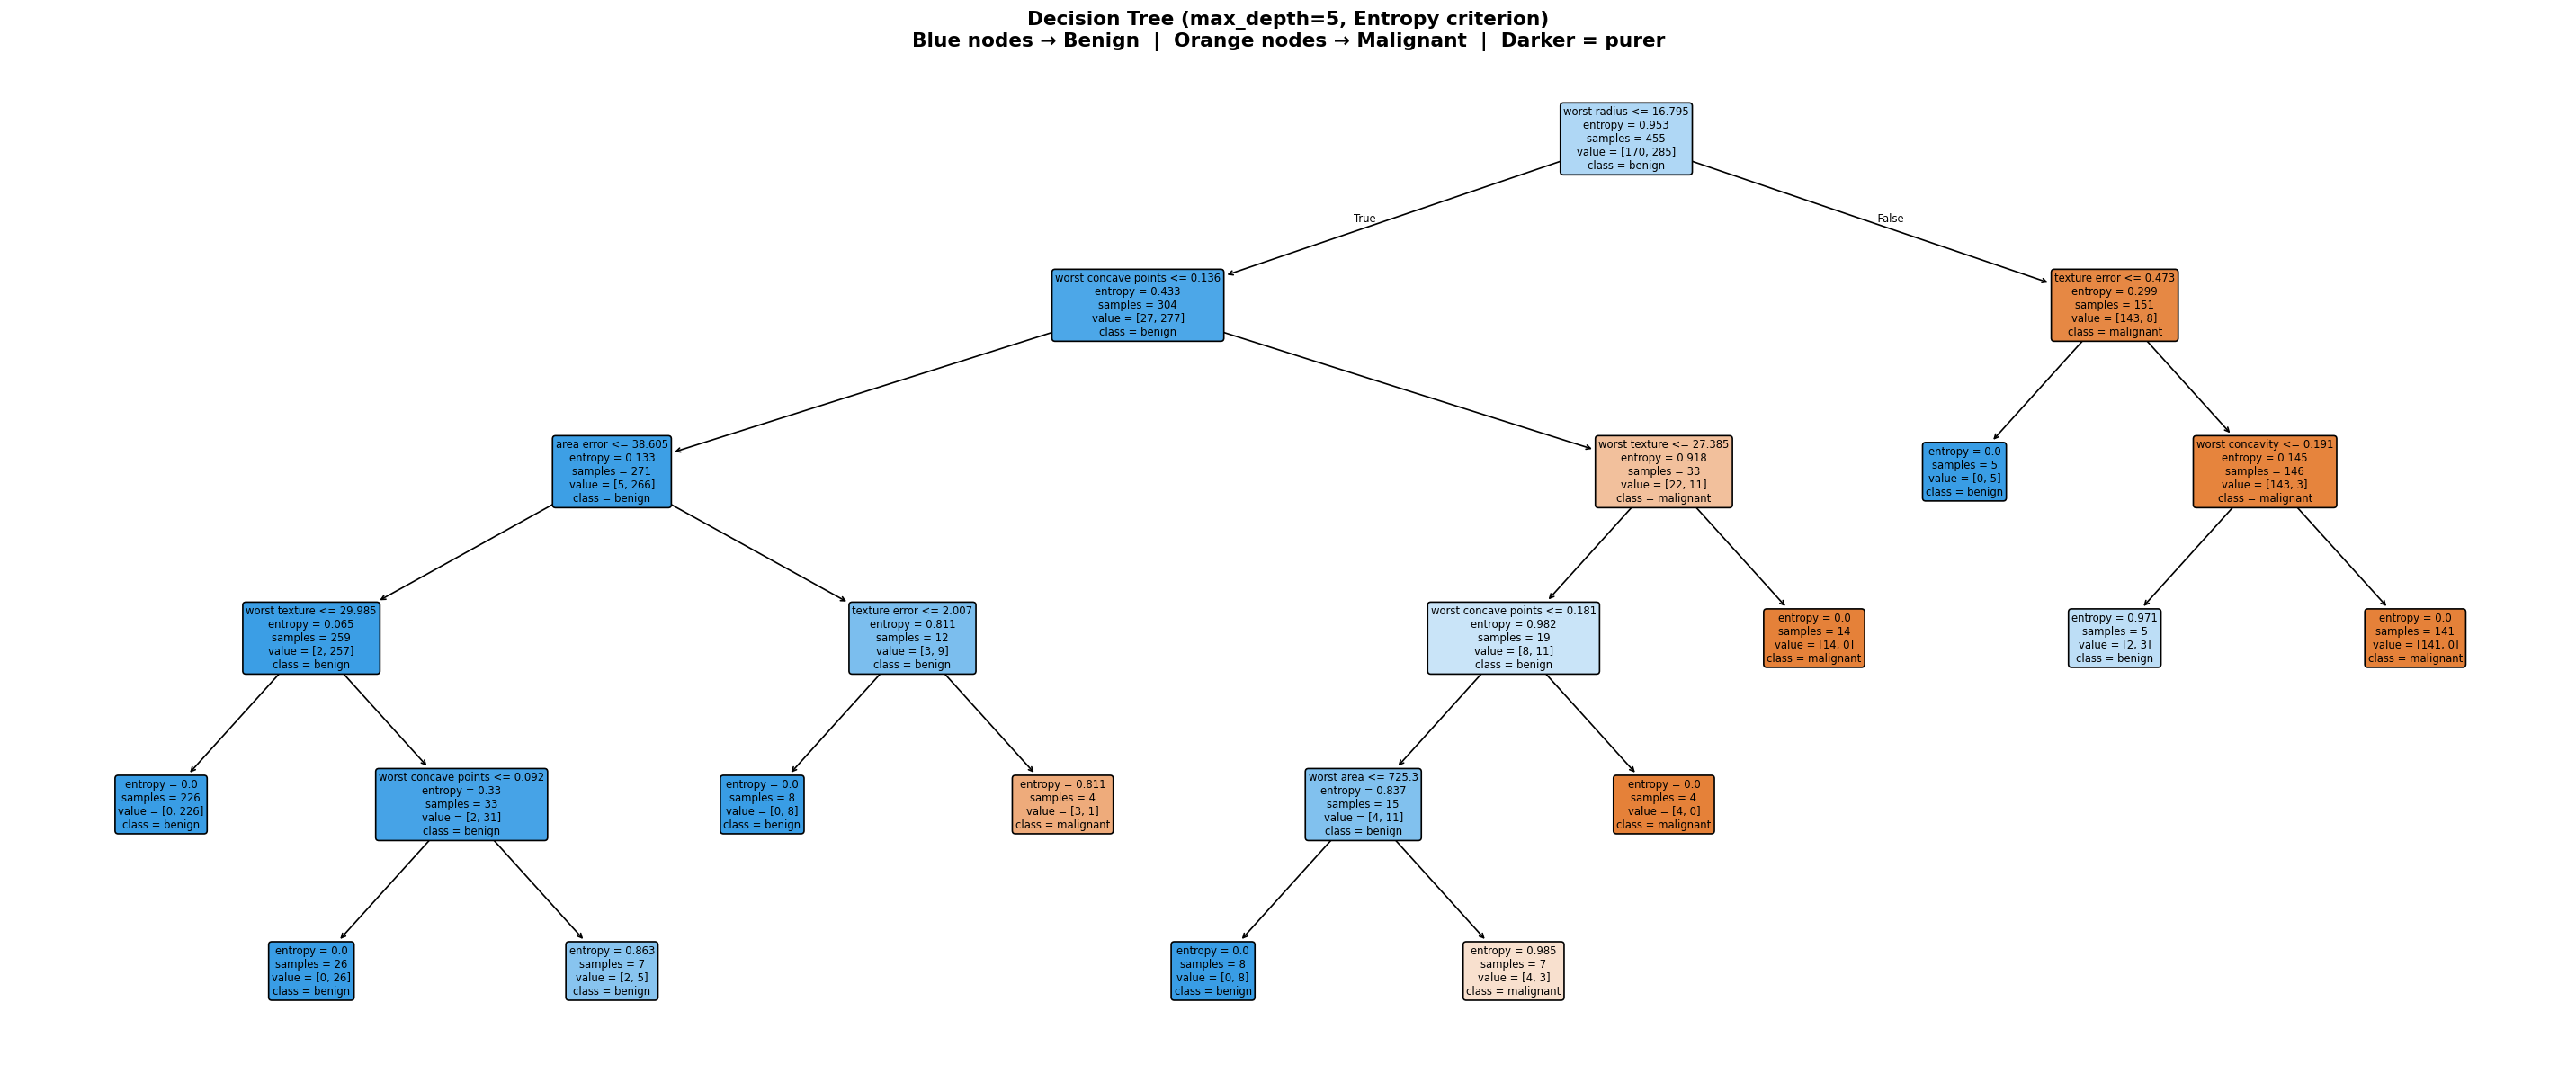

In [17]:
# ── Visualise with Graphviz (detailed) ─
# Export the sklearn tree (identical structure to scratch) via graphviz
dot_data = export_graphviz(
    dt_sk, out_file=None,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True, rounded=True,
    special_characters=True,
    impurity=True,        # show entropy at each node
    proportion=False,
    precision=3
)

# Render and save
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render('./decision_tree_full', cleanup=True)
print("✅ Full decision tree rendered decision_tree_full.png")

# Display inline (matplotlib)
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_sk,
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True, rounded=True,
          fontsize=7, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Decision Tree (max_depth=5, Entropy criterion)\n'
             'Blue nodes → Benign  |  Orange nodes → Malignant  |  Darker = purer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


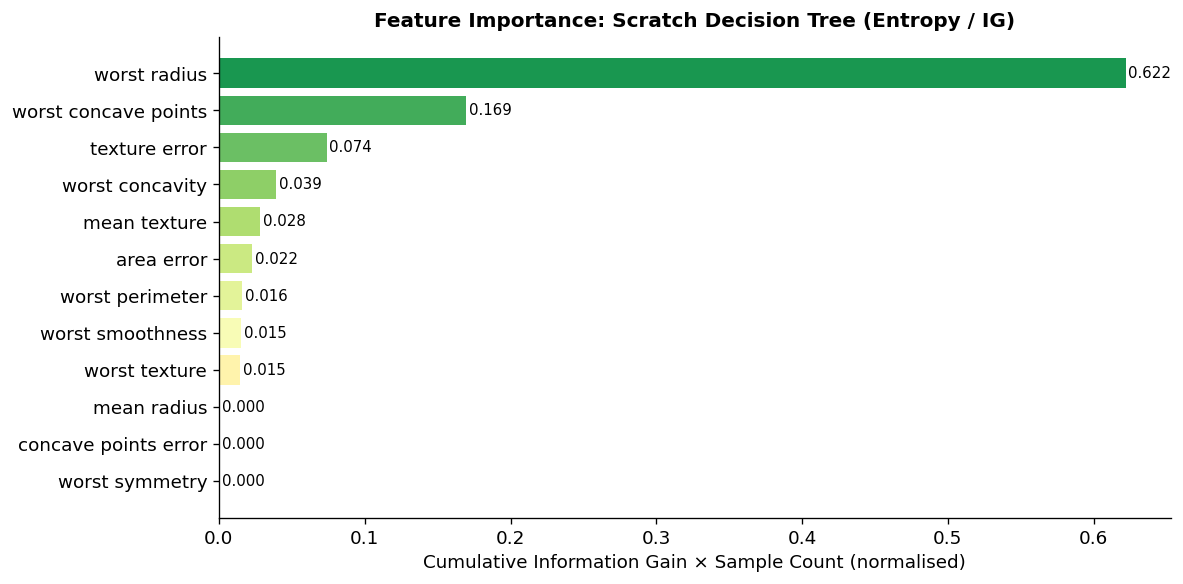

In [18]:
# ── Feature importance from scratch tree ─
importance_df = pd.DataFrame({
    'Feature'   : data.feature_names,
    'Importance': dt_scratch.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importance_df['Feature'][::-1],
               importance_df['Importance'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importance_df))))
ax.set_xlabel('Cumulative Information Gain × Sample Count (normalised)')
ax.set_title('Feature Importance: Scratch Decision Tree (Entropy / IG)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()



## Ensemble Methods: Bagging, Random Forest & Gradient Boosting

### 4.1 The Big Idea

A single model is fragile. Ensembles **combine many weak learners** to build a strong one.  
Three dominant strategies:

| Method | Core Idea | Bias | Variance |
|--------|-----------|------|---------|
| **Bagging** | Train on bootstrap samples, average predictions | Same as base | ↓ Reduced |
| **Random Forest** | Bagging + random feature subsets per split | Slight ↑ | ↓↓ Reduced more |
| **Gradient Boosting** | Sequentially correct residuals | ↓ Reduced | Can ↑ if over-tuned |

### 4.2 Bagging (Bootstrap Aggregating)

**Bootstrap sample:** Sample $n$ points **with replacement** from training set of size $n$.  
Each base learner sees ~63.2% of unique training samples on average.

$$\hat{f}_{bag}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}^{(b)}(x)$$

**Variance reduction** (for independent, identically distributed estimators):

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B \hat{f}^{(b)}\right) = \frac{\sigma^2}{B}$$

### 4.3 Random Forest

Bagging + **feature randomisation** at each split: only $m = \lfloor \sqrt{p} \rfloor$ features considered.  
This **decorrelates** the trees, giving larger variance reduction than plain bagging.


### 4.4 Gradient Boosting

Builds trees **sequentially**, each fitting the **negative gradient** (pseudo-residuals) of a loss function.

**Update rule:**

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $h_m$ fits the residuals $r_i = -\left[\frac{\partial \mathcal{L}(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$ and $\eta$ is the learning rate.

For log-loss (binary classification): $r_i = y_i - p_i$ (actual minus predicted probability).


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# HELPER: Bootstrap sampling
# ══════════════════════════════════════════════════════════════════════════

def bootstrap_sample(X, y, seed=None):
    """
    Draw a bootstrap sample (with replacement) of size n from (X, y).
    Returns: (X_boot, y_boot, oob_indices)
    """
    rng = np.random.default_rng(seed)
    n = len(y)
    indices = rng.integers(0, n, size=n)
    oob     = np.setdiff1d(np.arange(n), np.unique(indices))
    return X[indices], y[indices], oob

# Demonstrate
X_b, y_b, oob = bootstrap_sample(X_train, y_train, seed=0)
frac_seen = len(np.unique(np.where(np.isin(np.arange(len(y_train)),
                                            np.setdiff1d(np.arange(len(y_train)), oob)))[0])) / len(y_train)
print(f"Bootstrap sample size  : {len(y_b)}")
print(f"Unique samples seen    : {len(y_train) - len(oob)} ({frac_seen:.1%})")
print(f"Out-of-bag (OOB) count : {len(oob)} ({len(oob)/len(y_train):.1%})")
print(f"\n💡 Theoretically: lim_{{n→∞}} (1 - 1/n)^n = 1/e ≈ 36.8% OOB → {1/math.e:.1%}")


Bootstrap sample size  : 455
Unique samples seen    : 291 (64.0%)
Out-of-bag (OOB) count : 164 (36.0%)

💡 Theoretically: lim_{n→∞} (1 - 1/n)^n = 1/e ≈ 36.8% OOB → 36.8%


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH: Bagging Classifier
# ══════════════════════════════════════════════════════════════════════════

class BaggingScratch:
    """
    Bagging ensemble of DecisionTreeScratch estimators.
    
    Parameters
    ----------
    n_estimators : int  — number of base learners
    max_depth    : int  — depth of each tree
    """
    def __init__(self, n_estimators=50, max_depth=5, min_samples_split=5,
                 min_samples_leaf=3):
        self.n_estimators     = n_estimators
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.estimators_      = []

    def fit(self, X, y):
        self.estimators_ = []
        for i in range(self.n_estimators):
            X_b, y_b, _ = bootstrap_sample(X, y, seed=SEED + i)
            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X_b, y_b)
            self.estimators_.append(tree)
        return self

    def predict(self, X):
        """Majority vote across all trees."""
        # Shape: (n_estimators, n_samples)
        votes = np.array([t.predict(X) for t in self.estimators_])
        # Majority vote per sample
        return np.apply_along_axis(
            lambda col: Counter(col).most_common(1)[0][0], axis=0, arr=votes
        )

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print("BaggingScratch class defined")


BaggingScratch class defined


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH: Random Forest
# ══════════════════════════════════════════════════════════════════════════

class RandomForestScratch:
    """
    Random Forest = Bagging + random feature subset at each split.
    
    Uses a modified DecisionTreeScratch that considers only max_features features per split.
    """
    def __init__(self, n_estimators=100, max_depth=None, max_features='sqrt',
                 min_samples_split=2, min_samples_leaf=1):
        self.n_estimators     = n_estimators
        self.max_depth        = max_depth
        self.max_features     = max_features
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.estimators_      = []
        self.feat_subsets_    = []
        self.feature_importances_ = None

    def _n_features(self, p):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(p)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(p)))
        elif isinstance(self.max_features, int):
            return self.max_features
        return p

    def fit(self, X, y):
        p = X.shape[1]
        m = self._n_features(p)
        importances = np.zeros(p)
        self.estimators_   = []
        self.feat_subsets_ = []

        for i in range(self.n_estimators):
            rng = np.random.default_rng(SEED + i)
            # Random feature subset
            feat_subset = rng.choice(p, size=m, replace=False)
            self.feat_subsets_.append(feat_subset)

            # Bootstrap
            X_b, y_b, _ = bootstrap_sample(X, y, seed=SEED + i)
            X_b_sub = X_b[:, feat_subset]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X_b_sub, y_b)
            self.estimators_.append(tree)

            # Accumulate importances mapped back to global indices
            for local_i, global_i in enumerate(feat_subset):
                if local_i < len(tree.feature_importances_):
                    importances[global_i] += tree.feature_importances_[local_i]

        self.feature_importances_ = importances / importances.sum() if importances.sum() > 0 else importances
        return self

    def predict(self, X):
        votes = []
        for tree, feat_subset in zip(self.estimators_, self.feat_subsets_):
            votes.append(tree.predict(X[:, feat_subset]))
        votes = np.array(votes)
        return np.apply_along_axis(
            lambda col: Counter(col).most_common(1)[0][0], axis=0, arr=votes
        )

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print(f"RandomForestScratch class defined")
print(f"   Features per split (sqrt rule): {int(np.sqrt(X_train.shape[1]))} of {X_train.shape[1]}")


RandomForestScratch class defined
   Features per split (sqrt rule): 5 of 30


In [22]:
# ══════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH: Gradient Boosting (binary classification)
# ══════════════════════════════════════════════════════════════════════════

class GradientBoostingScratch:
    """
    Gradient Boosting Classifier for binary classification.
    Loss: log-loss (binary cross-entropy)
    Weak learner: shallow DecisionTreeScratch (regression-like via mean)

    Update: F_m(x) = F_{m-1}(x) + η · h_m(x)
    Pseudo-residuals: r_i = y_i - sigmoid(F_{m-1}(x_i))
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3,
                 min_samples_split=5):
        self.n_estimators     = n_estimators
        self.learning_rate    = learning_rate
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.trees_           = []
        self.F0_              = None   # initial log-odds

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _fit_regression_tree(self, X, residuals):
        """Fit a regression tree to the pseudo-residuals (predict leaf means)."""
        # We reuse DecisionTreeScratch but override leaf values with mean residuals
        tree = DecisionTreeScratch(max_depth=self.max_depth,
                                   min_samples_split=self.min_samples_split)
        # Binarise residuals for structure (hacky but effective at shallow depths)
        labels = (residuals > 0).astype(int)
        tree.fit(X, labels)
        return tree, residuals   # store residuals for leaf value override

    def _predict_raw(self, X, tree, residuals_train, X_train):
        """Predict leaf mean residuals for new X."""
        leaf_preds_train = tree.predict(X_train)
        leaf_means = {}
        for leaf_val in np.unique(leaf_preds_train):
            mask = leaf_preds_train == leaf_val
            leaf_means[leaf_val] = residuals_train[mask].mean()
        leaf_preds = tree.predict(X)
        return np.array([leaf_means.get(lv, 0.0) for lv in leaf_preds])

    def fit(self, X, y):
        y = y.astype(float)
        # Initial prediction: log-odds of the positive class
        p0 = np.clip(y.mean(), 1e-7, 1 - 1e-7)
        self.F0_ = np.log(p0 / (1 - p0))
        F = np.full(len(y), self.F0_)

        self.trees_      = []
        self.X_train_    = X.copy()

        for _ in range(self.n_estimators):
            p = self._sigmoid(F)
            residuals = y - p          # pseudo-residuals = negative gradient of log-loss
            tree, res = self._fit_regression_tree(X, residuals)
            update = self._predict_raw(X, tree, res, X)
            F += self.learning_rate * update
            self.trees_.append((tree, res))

        return self

    def predict_proba(self, X):
        F = np.full(len(X), self.F0_)
        for tree, res in self.trees_:
            F += self.learning_rate * self._predict_raw(X, tree, res, self.X_train_)
        return self._sigmoid(F)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

print("GradientBoostingScratch class defined")


GradientBoostingScratch class defined


In [23]:
# ── Train all scratch ensembles ─
results = {}

# -- Bagging --
print("Training Bagging (scratch)...", end=' ')
t0 = time.time()
bag_scratch = BaggingScratch(n_estimators=50, max_depth=5)
bag_scratch.fit(X_train, y_train)
bag_time = time.time() - t0
bag_acc  = bag_scratch.score(X_test, y_test)
results['Bagging (Scratch)'] = {'acc': bag_acc, 'time': bag_time}
print(f"acc={bag_acc:.4f}  ({bag_time:.2f}s)")

# -- Random Forest --
print("Training Random Forest (scratch)...", end=' ')
t0 = time.time()
rf_scratch = RandomForestScratch(n_estimators=100, max_depth=8,
                                  min_samples_split=5, min_samples_leaf=3)
rf_scratch.fit(X_train, y_train)
rf_time = time.time() - t0
rf_acc  = rf_scratch.score(X_test, y_test)
results['Random Forest (Scratch)'] = {'acc': rf_acc, 'time': rf_time}
print(f"acc={rf_acc:.4f}  ({rf_time:.2f}s)")

# -- Gradient Boosting --
print("Training Gradient Boosting (scratch)...", end=' ')
t0 = time.time()
gb_scratch = GradientBoostingScratch(n_estimators=80, learning_rate=0.1, max_depth=3)
gb_scratch.fit(X_train, y_train)
gb_time = time.time() - t0
gb_acc  = gb_scratch.score(X_test, y_test)
results['Gradient Boosting (Scratch)'] = {'acc': gb_acc, 'time': gb_time}
print(f"acc={gb_acc:.4f}  ({gb_time:.2f}s)")


Training Bagging (scratch)... acc=0.9474  (24.01s)
Training Random Forest (scratch)... acc=0.9474  (9.21s)
Training Gradient Boosting (scratch)... acc=0.9561  (56.25s)


In [24]:
# ── sklearn ensemble comparison ─

# Bagging
print("Training Bagging (sklearn)...", end=' ')
t0 = time.time()
bag_sk = BaggingClassifier(n_estimators=50, max_samples=1.0, bootstrap=True,
                            random_state=SEED)
bag_sk.fit(X_train, y_train)
bag_sk_time = time.time() - t0
bag_sk_acc  = bag_sk.score(X_test, y_test)
results['Bagging (sklearn)'] = {'acc': bag_sk_acc, 'time': bag_sk_time}
print(f"acc={bag_sk_acc:.4f}  ({bag_sk_time:.2f}s)")

# Random Forest
print("Training Random Forest (sklearn)...", end=' ')
t0 = time.time()
rf_sk = RandomForestClassifier(n_estimators=100, max_depth=None,
                                min_samples_split=5, min_samples_leaf=3,
                                max_features='sqrt', random_state=SEED, n_jobs=-1)
rf_sk.fit(X_train, y_train)
rf_sk_time = time.time() - t0
rf_sk_acc  = rf_sk.score(X_test, y_test)
results['Random Forest (sklearn)'] = {'acc': rf_sk_acc, 'time': rf_sk_time}
print(f"acc={rf_sk_acc:.4f}  ({rf_sk_time:.2f}s)")

# Gradient Boosting
print("Training Gradient Boosting (sklearn)...", end=' ')
t0 = time.time()
gb_sk = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                    max_depth=3, random_state=SEED)
gb_sk.fit(X_train, y_train)
gb_sk_time = time.time() - t0
gb_sk_acc  = gb_sk.score(X_test, y_test)
results['Gradient Boosting (sklearn)'] = {'acc': gb_sk_acc, 'time': gb_sk_time}
print(f"acc={gb_sk_acc:.4f}  ({gb_sk_time:.2f}s)")


Training Bagging (sklearn)... acc=0.9386  (0.13s)
Training Random Forest (sklearn)... acc=0.9561  (0.07s)
Training Gradient Boosting (sklearn)... acc=0.9561  (0.23s)


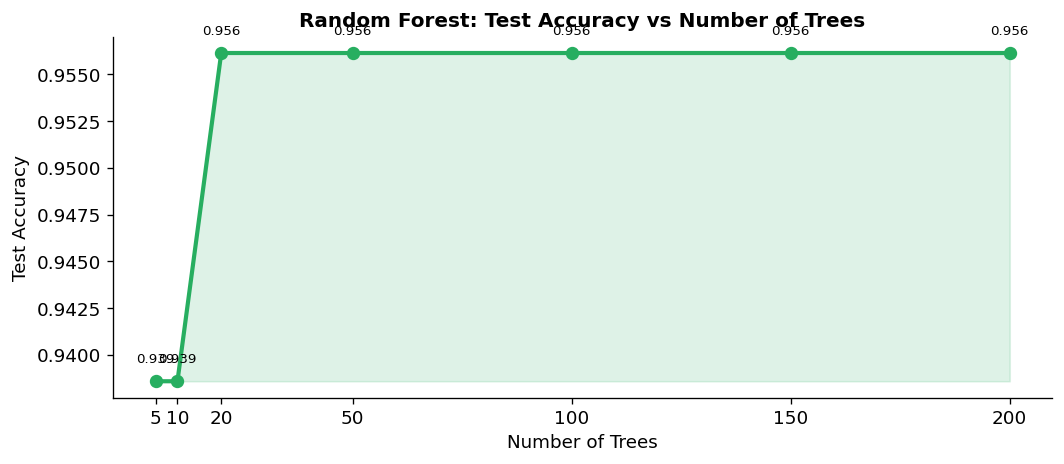

In [25]:
# ── n_estimators vs accuracy (Random Forest) ─
n_range = [5, 10, 20, 50, 100, 150, 200]
rf_test_accs = []
for n in n_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                    random_state=SEED, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    rf_test_accs.append(rf_tmp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_range, rf_test_accs, 'o-', color='#27ae60', linewidth=2.5, markersize=7)
ax.fill_between(n_range, [min(rf_test_accs)]*len(n_range), rf_test_accs,
                alpha=0.15, color='#27ae60')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: Test Accuracy vs Number of Trees'
             , fontsize=12, fontweight='bold')
ax.set_xticks(n_range)
for x, y_ in zip(n_range, rf_test_accs):
    ax.text(x, y_ + 0.001, f'{y_:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


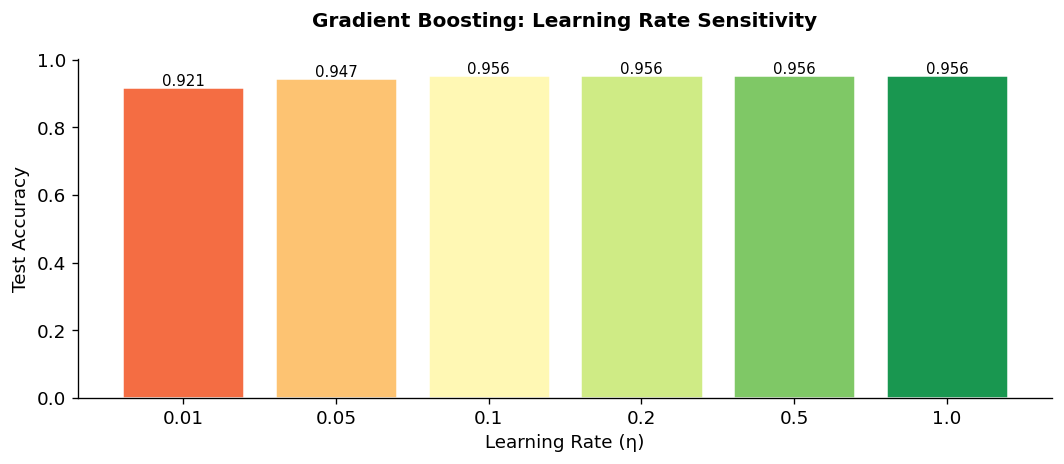

In [26]:
# ── Gradient Boosting — learning rate sensitivity ─
lr_vals = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
gb_lr_accs = []
for lr in lr_vals:
    gb_tmp = GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                                         max_depth=3, random_state=SEED)
    gb_tmp.fit(X_train, y_train)
    gb_lr_accs.append(gb_tmp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(lr_vals)), gb_lr_accs,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(lr_vals))),
              edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(lr_vals)))
ax.set_xticklabels([str(lr) for lr in lr_vals])
ax.set_xlabel('Learning Rate (η)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Gradient Boosting: Learning Rate Sensitivity\n', 
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, gb_lr_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


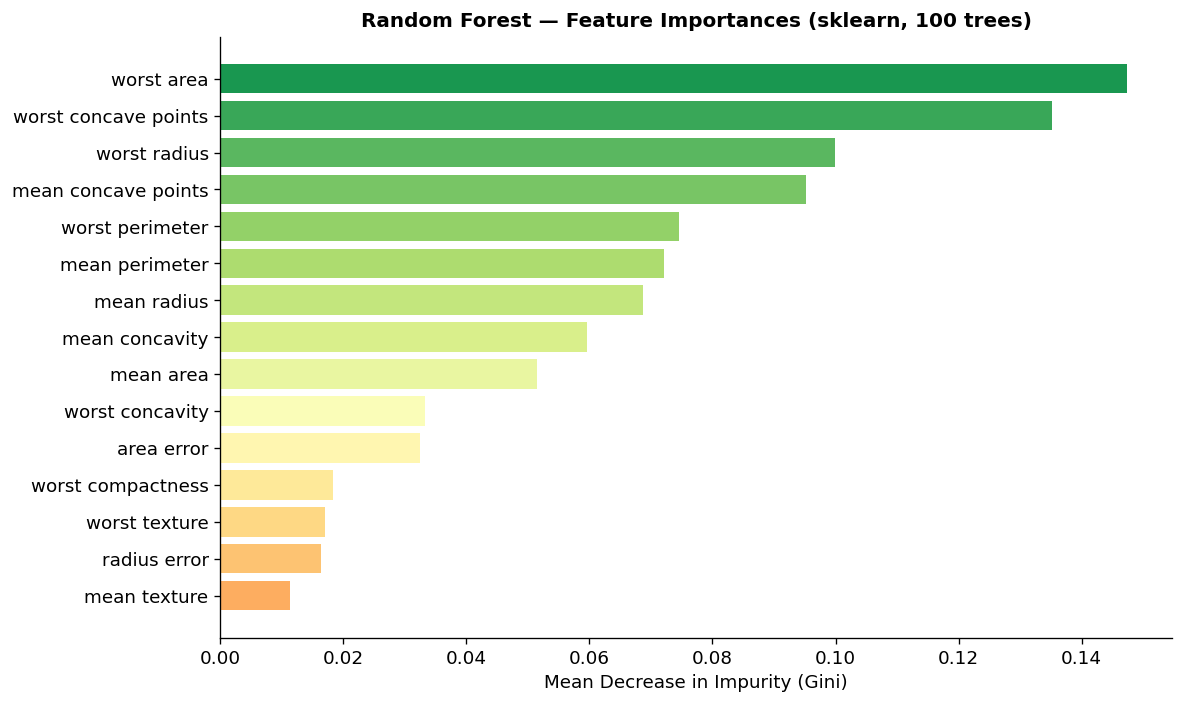

In [27]:
# ── Feature importances — Random Forest ─
rf_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'RF_Importance': rf_sk.feature_importances_
}).sort_values('RF_Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(rf_importance_df)))
ax.barh(rf_importance_df['Feature'][::-1],
        rf_importance_df['RF_Importance'][::-1],
        color=colors_bar)
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Random Forest — Feature Importances (sklearn, 100 trees)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


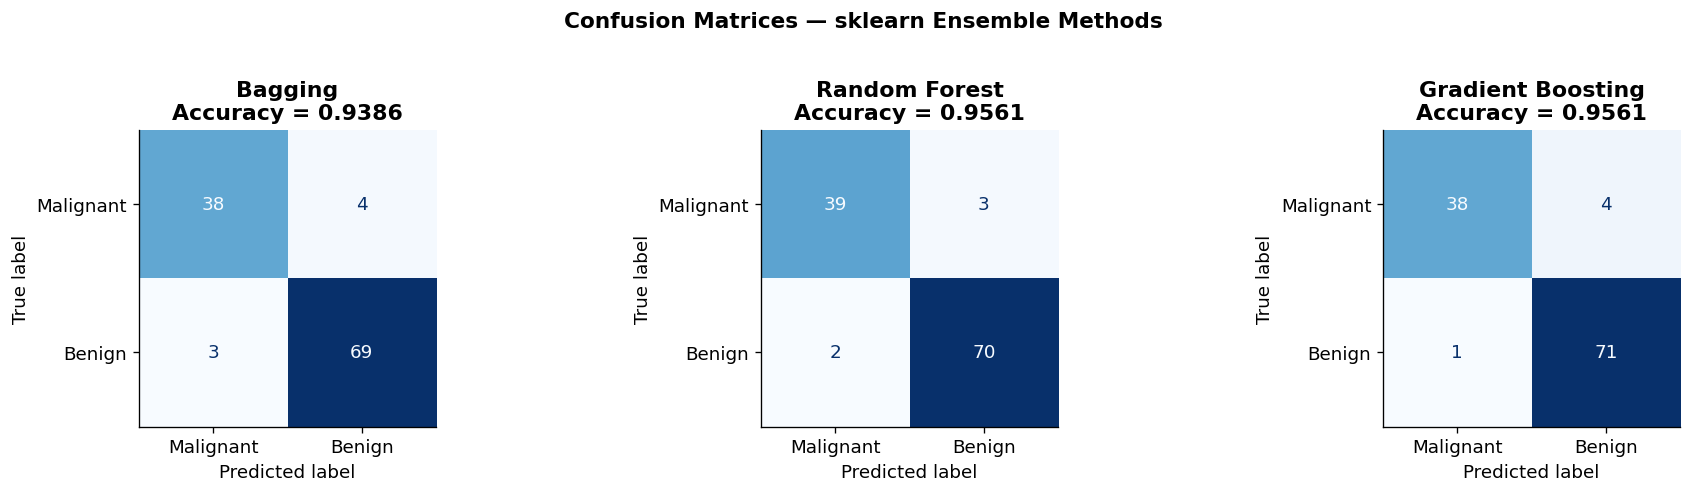

In [28]:
# ── Confusion matrices side-by-side ─
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    (bag_sk,  'Bagging'),
    (rf_sk,   'Random Forest'),
    (gb_sk,   'Gradient Boosting'),
]
for ax, (model, name) in zip(axes, configs):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy = {model.score(X_test, y_test):.4f}',
                 fontweight='bold')

plt.suptitle('Confusion Matrices — sklearn Ensemble Methods', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
